# W8 Linear Regression, Logistic Regression, L1L2 Grid Search

## Model 1

### Importing Data

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, roc_curve, roc_auc_score, f1_score
import numpy as np
import seaborn as sns

In [23]:
df=pd.read_csv("titanicdataset.csv", header=1)
df.rename(columns={df.columns[3]: 'name'}, inplace=True)# replacing the 4th column with name
df.head()

,sn,pclass,survived,name,gender,age,family,fare,embarked,date
0,1,3,0,Mr. Anthony,male,42,0.0,7.55,NaN,01-Jan-90
1,1,3,0,Mr. Anthony,male,42,0.0,7.55,NaN,01-Jan-90
2,2,3,0,Master. Eugene Joseph,male,?,2.0,20.25,S,02-Jan-90
3,3,2,0,"Abbott, Mr. Rossmore Edward",NaN,NaN,2.0,**,S,03-Jan-90
4,4,3,1,"Abbott, Mr. Rossmore Edward",female,35,2.0,20.25,S,04-Jan-90


### Cleaning Data

In [28]:
clean_df= df.copy()
clean_df=clean_df.replace({'?': np.nan, '**': np.nan})
clean_df['age']=pd.to_numeric(clean_df['age'])#changing age to integer
clean_df['fare']=pd.to_numeric(clean_df['fare'])#changing fare to integer
clean_df['age']=clean_df['age'].fillna(clean_df['age'].median())#filling age with median
clean_df['fare']=clean_df['fare'].fillna(clean_df['fare'].median())#filling empty fares with median
clean_df['family']=clean_df['family'].fillna(clean_df['family'].median())#filling empty family values with median
clean_df['gender']=clean_df['gender'].fillna('male')#filling NaNs with male
clean_df['gender']=clean_df['gender'].map({'male': 0, 'female': 1})
clean_df.head()

,sn,pclass,survived,name,gender,age,family,fare,embarked,date
0,1,3,0,Mr. Anthony,0,42.0,0.0,7.5500,NaN,01-Jan-90
1,1,3,0,Mr. Anthony,0,42.0,0.0,7.5500,NaN,01-Jan-90
2,2,3,0,Master. Eugene Joseph,0,28.0,2.0,20.2500,S,02-Jan-90
3,3,2,0,"Abbott, Mr. Rossmore Edward",0,28.0,2.0,14.4542,S,03-Jan-90
4,4,3,1,"Abbott, Mr. Rossmore Edward",1,35.0,2.0,20.2500,S,04-Jan-90


### Logistic Regression

In [42]:
from sklearn.preprocessing import StandardScaler
X=clean_df.drop(['sn','survived','name','date','embarked'], axis=1)
y=clean_df['survived']

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.20, random_state=1)

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
log_reg=LogisticRegression()
param_grid={
    'penalty':['l1','l2'],
    'C':[0.001, 0.01, 0.1, 1, 10, 100],
    'solver':['liblinear']
}
model1 = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy')
model1.fit(Xtrain, ytrain)

print(f"Best Penalty: {model1.best_params_['penalty']}")
print(f"Best C: {model1.best_params_['C']}")

best_log_model=model1.best_estimator_

Best Penalty: l2
Best C: 0.1


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

### Result Interpretation

- L2 was the best penalty
- Because L2 is better, it suggests that most features contribute some information and you just need to prevent the model from overfitting
- Best C parameter was 0.1
- A C value of 0.1 is on the smaller side, which indicates that the grid search found that a simpler, more conservative model actually generalizes better to unseen data

### Evalutation of Model

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


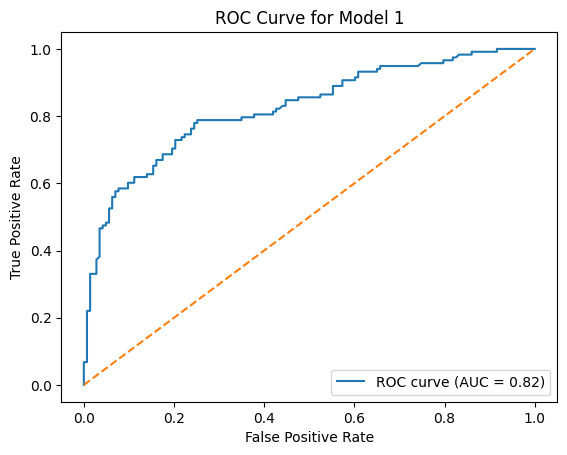

In [62]:
y_prob = model1.predict_proba(Xtest)[:, 1]
auc_score=roc_auc_score(y_test, y_prob)
fpr, tpr, thresholds = roc_curve(ytest, y_prob)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Model 1")
plt.legend(loc="lower right")
plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


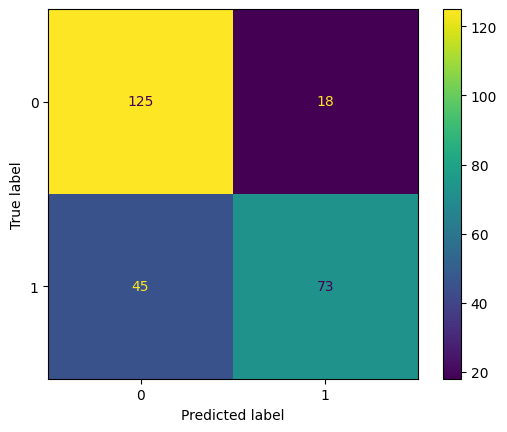

In [63]:
ypred = model1.predict(Xtest)
ConfusionMatrixDisplay.from_predictions(ytest, ypred)

In [69]:
print(f'Accuracy:{accuracy_score(ytest, ypred):.2f}')
print(f'Precision:{precision_score(ytest, ypred):.2f}')
print(f'Recall:{recall_score(ytest, ypred):.2f}')
print(f'F1:{f1_score(ytest, ypred):.2f}')

Accuracy:0.76
Precision:0.80
Recall:0.62
F1:0.70


- The most appropriate metric for this problem is precision, because it is important that when the model predicts a passenger survived, that prediction is correct.
- A high precision of 0.80 means that most predicted survivors acutally survived, so the model avoids falsely labelling passengers as suvivors when they did not survive.
- While recall is lower, prioritizing precision reduces the risk of incorrectly predicting survival

### Logistic vs. Linear

- It is not approriate to use linear regression for this problem because the outcome variable is binary.
- Log regression is specifically designed for classification tasks
- Linea

## Model 2

In [3]:
model2_df=pd.read_csv('top2019.csv')
model2_df.head()

,id,name,artists,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,6v3KW9xbzN5yKLt9YKDYA,Señorita,Shawn Mendes,0.759,0.548,9.0,-6.049,0.0,0.0290,0.0392,0.00,0.0828,0.749,116.967,190800.0,4.0
1,2Fxmhks0bxGSBdJ92vM42,bad guy,Billie Eilish,0.701,0.425,7.0,-10.965,1.0,0.3750,0.3280,0.13,0.1000,0.562,135.128,194088.0,4.0
2,0RiRZpuVRbi7oqRdSMwhQ,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,0.755,0.522,2.0,-4.368,1.0,0.0575,0.5330,0.00,0.0685,0.925,89.960,157560.0,4.0
3,6ocbgoVGwYJhOv1GgI9Ns,7 rings,Ariana Grande,0.778,0.317,1.0,-10.732,0.0,0.3340,0.5920,0.00,0.0881,0.327,140.048,178627.0,4.0
4,2YpeDb67231RjR0MgVLzs,Old Town Road - Remix,Lil Nas X,0.878,0.619,6.0,-5.560,1.0,0.1020,0.0533,0.00,0.1130,0.639,136.041,157067.0,4.0


In [4]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
numeric_df=model2_df.drop(columns=['id','name','artists','time_signature'])
normalized_df=pd.DataFrame(scaler.fit_transform(numeric_df), columns=numeric_df.columns)
normalized_df.head()

,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.733813,0.551072,0.818182,0.713406,0.0,0.000000,0.035020,0.000000,0.066913,0.756010,0.421259,0.322394
1,0.629496,0.395965,0.636364,0.298659,1.0,1.000000,0.331874,0.802469,0.112223,0.531250,0.588074,0.336019
2,0.726619,0.518285,0.181818,0.855227,1.0,0.082370,0.542590,0.000000,0.029241,0.967548,0.173190,0.184651
3,0.767986,0.259773,0.090909,0.318316,0.0,0.881503,0.603236,0.000000,0.080875,0.248798,0.633266,0.271950
4,0.947842,0.640605,0.545455,0.754661,1.0,0.210983,0.049513,0.000000,0.146470,0.623798,0.596460,0.182608


### Feature Selection

In [5]:
corr_matrix=normalized_df.corr()
dance_corr=corr_matrix["danceability"].sort_values(ascending=False)
print(dance_corr)

danceability        1.000000
valence             0.391774
energy              0.273068
speechiness         0.227283
loudness            0.178688
key                 0.165208
instrumentalness    0.153419
tempo               0.149066
mode                0.007662
liveness           -0.088595
duration_ms        -0.132798
acousticness       -0.465118
Name: danceability, dtype: float64


- looking at the correlation between danceability and the other columns, the three strongest predictors are valence, energy, and acousticness
- even a strong negative correlation is still powerful for predicition

In [6]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
features = ["valence", "energy", "acousticness"]
X=normalized_df[features]
y=normalized_df['danceability']

In [8]:
Xtrain, Xtest, ytrain, ytest= train_test_split(X, y, test_size=0.2, random_state=2)

param_grid={'alpha': [0.001, 0.01, 0.1, 1, 10, 100], #alpha decides weights #whether to center the data
            'fit_intercept': [True, False], #whether to center the data
            'tol': [1e-4, 1e-3, 1e-2], #convergence tolerance
           } 

lasso=Lasso()
lasso_grid= GridSearchCV(lasso, param_grid, cv=5, scoring='neg_mean_squared_error', refit=True)
#refit means to refit best model on the training set
lasso_grid.fit(Xtrain, ytrain)

print(f'Best Parameters: {lasso_grid.best_params_}')
y_pred_lasso=lasso_grid.predict(Xtest)
print(f'Lasso R^2 Score: {r2_score(ytest, y_pred_lasso)}')
print(f'Lasso Coefficients:{lasso_grid.best_estimator_.coef_}')

Best Parameters: {'alpha': 0.001, 'fit_intercept': True, 'tol': 0.0001}
Lasso R^2 Score: 0.3411889356630504
Lasso Coefficients:[ 0.28852437 -0.11856333 -0.37739243]


**Results Interpretation**
- The R^2 score is relatively low at 0.34. The model explains only 34% of variance in the target variable
- Best alpha=0.001, which means the penalty barely helps
- Lasso zeroed nothing out significantly, suggesting all 3 features matter somewhat

In [9]:
ridge=Ridge()
ridge_grid=GridSearchCV(ridge, param_grid, cv=5)
ridge_grid.fit(Xtrain, ytrain)

print(f'Best Parameters: {ridge_grid.best_params_}')

y_pred_ridge= ridge_grid.predict(Xtest)
print(f'Ridge R^2 Score: {r2_score(ytest, y_pred_ridge)}')
print(f'Ridge Coefficients:{ridge_grid.best_estimator_.coef_}')

Best Alpha: {'alpha': 10, 'fit_intercept': True, 'tol': 0.0001}
Ridge R^2 Score: 0.2494362447403876
Ridge Coefficients:[ 0.07098815  0.02810658 -0.09151952]


**Results Interpretation**
- The R^2 score is relatively low at 0.249, which is worse than lasso, and only 25% of variance is explained
- Best alpha is 10, which is stronger regularization, so shrinking coefficients heavily toward zero
- Lasso outperformed Ridge

# W9 PCA

1. Unsupervised learning is when our data is not **explicitly labeled**, and we ask the algorithm to learn something meaningful on its own without labels.

2. The 2 types of unsupervised learning we will explore today are: **K-Means, PCA (principal component analysis)**

3. What is a centroid? Take some time on this question after reading under the K-Means block in the ipynb. Draw some of your understanding out on the board! Include some formulas if you can. 
**A centroid is a mean/average point
idx=findClosestCentroids(X, centroids);
centroids = computeMeans (X, idx, K);**

4. Under line 7, the blue points represent **data points** and the stars represent **centroids.**

5. Write the formula for finding the closest centroids on the board, and then summarize it using your own words here.
**Finding the distance by minimizing the square magnitude of the position of x(i) minus the position of the centroid**

6. Read the code in line 8. Name the type of python object each of these are: 
- **centroids -> float**
- **X-> array**
- **np.square -> method**
- **min_distance -> integer/float**
- **idx -> float**

7. What is the purpose of line 9?
**It outputs the closest centroid for the first three datapoints**

8. What is the difference between the first plot under line 7 versus the one in line 10? 
**The first plot only has 1 cluster while the second one has three plots**

9. On the board, write the equation under 'Computing Centroid Means' and label each of the variables. On your canvas submission, write 2 sentences on what this equation represents. 
**The equation is computing a weighted average of k cluster  by adding up all the x(i)s in the cluster (assigned to its centroid), and dividing by the set.**

10. Challenge: What is the purpose of line 17-24?
**Runs the KMeans loop for a fixed number of iterations and tracks centroids**

11. Line 25 onwards shows you how to do exactly what the above lines did with hard code. That means that scikit learn has an inbuilt function for all the things we just hand-coded! Yay! Write the code that helps you do what we did faster here:

**from sklearn.cluster import KMeans**

**km1= KMeans (3)** 

**km1.fit (X1)** 

12. Look up the parameters for Kmeans and explain them here! 
- **n_clusters: # of clusters to form** 
- **init: method for initialization**
- **n_init: # of times the k-means algorithm is run with different centroid seeds**
- **max_iter: max number of iterations**
- **tol: relative tolerance with regards to Frobenius norm of the difference in the cluster centers of two consecutive iterations to declare convergence.**
- **verbose: verbosity mode**
- **random_state: determines random number generation**
- **copy_x: if to make a copy of x**
- **algorithm: kmeans algorithm to use**

13. Check out the image compression example from lines 27-36, and write at least 3 questions on the board that you have about it (if you don't have any questions, write 3 'takeaways'.
14. It's PCA time. What type of object is X3 in line 39? 
**X3 is an array/matrix with 50 rows and 2 columns**
15. What type of normalization are they doing for this data? 
**This is a z-score normalization/standardization** 
16. Vectors are kinda hard. Find a resource online to help you understand #3-- I'm here to help! Insert the resource here.
**https://www.youtube.com/watch?v=PFDu9oVAE-g**
17. In line 42, what is the purpose of this function, and what type of objects is the function returning? 
**The function does all three steps from the previous image, and performs the PCA. The function returns 6 objects:**
- Mean - float
- Std - float
- X_norm- float
- U- array (list of lists)
- S - list
- V - array (list of lists)

18. Don't worry about all the particularities of line 47, data visualization is it's own class and specialty, but check out the graph. Read the paragraph just below and explain it in a sentence in normal-people speak here. I would ignore the paragraph after that unless you're feeling brave. 
**Since most of the data’s spread is following the line y=x, PCA lets us change the 2D data to just 1 D by projecting every point onto that black line.**

19. Skip ahead to the graph under line 54. Write a sentence about what this is doing for me. 
Each blue dot is the original 2D data and now they have been aligned to the diagonal line. **The dashed lines represent the small amount of information that gets lost in that compression.**
20. Lines 55 do the thing that happened in the above lines for PCA with an in-built function in scikit learn. Insert the code here:

**from sklearn.decomposition import PCA**

**pca= PCA (n_components= 2)**

**pca_result= pca.fit_transform(X3)** 

21. In the code you just wrote above, where did X3 even come from? What is it? And what is n_components anyway? 
**X3 was an array defined earlier that contains all the data. n_components tells PCA how many dimensions you want to keep after compression. Here n_components=2 is actually the same dimensionality as X3, so its actually not doing anything.**
22. Somewhere before the graph are a few sentences that I would like you to comprehend: 
pca_result: (50, 2)
Variation per principal component: [0.87062385 0.12937615]
The above ratio is how much of the variance or variability in our data is captured by the two principal components.
You may have to look this up, but what does the (50, 2) mean? And in normal people speak, what does the output for Variation per principal component mean? 
- **(50, 2) is the shape of the output array. It means that the first principal component (the black diagonal line) captures 87% of all the variability in the data, while the second component only captures the remaining 13%.**

